##**Persiapkan Lingkungan**

Membuat simulasi pasar untuk 1 produk, beberapa pilihan harga, dan pelanggan yang berperilaku probabilistik. Data yang disimpan:
- Daftar harga yang bisa dipilih agent
- Probabilitas pelanggan membeli pada harga tersebut

Metode pull:
- Simulasi pelanggan yang stokastik antara:
  - Pembelian terjadi
  - Tidak ada pembelian

**Dynamic Pricing Environment:**
- Setiap arm memiliki peluang beli yang konstan
- Lingkungan tidak berubah
- Tidak ada sensitivitas harga
- Reward = harga
- Tidak ada noise

**Realistic Dynamic Pricing Environment:**
- Prbabilitas beli dinamis berdasarkan selisih harga dan *willingness to pay* dengan fungsi sigmoid
- Lingkungan berubah mensimulasikan musim atau tren
- Ada sensitivitas harga
- Reward = profit
- Ada noise pasar

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
class DynamicPricingEnv:
  def __init__(self, prices, probs):
    self.prices = prices
    self.probs = probs

  def pull(self, arm):
    purchase = np.random.rand() < self.probs[arm]
    reward = self.prices[arm] if purchase else 0
    return reward

In [16]:
class RealisticDynamicPricingEnv:
    def __init__(self, prices, cost=4, base_value=12, beta=0.8, noise_std=0.05):
        self.prices = prices
        self.cost = cost
        self.base_value = base_value
        self.beta = beta
        self.noise_std = noise_std
        self.t = 0

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def pull(self, arm):
        price = self.prices[arm]

        seasonal = 2 * np.sin(2 * np.pi * self.t / 500)
        willingness = self.base_value + seasonal

        prob_buy = self._sigmoid(self.beta * (willingness - price))
        prob_buy += np.random.normal(0, self.noise_std)
        prob_buy = np.clip(prob_buy, 0, 1)

        purchase = np.random.rand() < prob_buy
        reward = (price - self.cost) if purchase else 0

        self.t += 1
        return reward


##**Kerangka Agent**

Kelas ini memaksa semua agent untuk bisa memilih aksi dan belajar dari reward tanpa peduli algoritma dan bagaimana internalnya bekerja.

In [17]:
class BanditAgent:
  def select_arm(self):
    raise NotImplementedError

  def update(self, arm, reward):
    raise NotImplementedError

##**Greedy Agent**

Agent Greedy tidak melakukan eksplorasi, tetapi selalu memilih arm dengan nilai estimasi tertinggi. Ia menyimpan berapa kali arm[i] pernah dipilih dan estimasi rata-rata reward arm[i].

In [18]:
class GreedyAgent(BanditAgent):
  def __init__(self, n_arms):
    self.counts = np.zeros(n_arms)
    self.values = np.zeros(n_arms)

  def select_arm(self):
    return np.argmax(self.values)

  def update(self, arm, reward):
    self.counts[arm] += 1
    self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

##**ε-Greedy (Exploration)**

Agent akan melakukan:
- Eksplorasi dengan probabilitas ε
- Eksploitasi dengan probabilitas 1 - ε

Eksplotasi dilakukan dengan greedy.

In [19]:
class EpsilonGreedy(BanditAgent):
  def __init__(self, n_arms, epsilon=0.1):
    self.epsilon = epsilon
    self.counts = np.zeros(n_arms)
    self.values = np.zeros(n_arms)

  def select_arm(self):
    if np.random.rand() < self.epsilon:
      return np.random.randint(len(self.values))
    return np.argmax(self.values)

  def update(self, arm, reward):
    self.counts[arm] += 1
    self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

##**UCB (Optimism Under Uncertainty)**

UCB memiliki ide bahwa dia akan optimis bahwa arm[i] mungkin bagus ketika dia belum yakin terhadap arm[i]. UCB melakukan eksplorasi yang tidak random dengan c dan menjamin setiap arm dicoba minimal 1x karena arm yang belum dicoba adalah ketidakpastian maksimum baginya.

Bonus:
- Arm jarang dicoba = bonus besar
- Arm sering dicoba = bonus kecil

Berbeda dengan Greedy, UCB tidak memilih nilai yang terbaik saat ini, tetapi memilih mana yang mungkin terbaik.

In [20]:
class UCBAgent(BanditAgent):
  def __init__(self, n_arms, c=2):
    self.c = c
    self.counts = np.zeros(n_arms)
    self.values = np.zeros(n_arms)
    self.total_pulls = 0

  def select_arm(self):
    self.total_pulls += 1
    ucb = np.zeros(len(self.values))

    for i in range(len(self.values)):
      if self.counts[i] == 0:
        return i
      bonus = self.c * np.sqrt(np.log(self.total_pulls) / self.counts[i])
      ucb[i] = self.values[i] + bonus

    return np.argmax(ucb)

  def update(self, arm, reward):
    self.counts[arm] += 1
    self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

##**Gradient Bandit (Policy-Based)**

Berbeda dengan Greedy, ε-Greedy, dan UCB yang bekerja berdasarkan value, Gradient Bandit bekerja berdasarkan *policy*. Ia memilih arm dengan mempertanyakan: "Apakah hasil kali ini lebih baik atau buruk dari biasanya?"
- Jika lebih baik dari rata-rata, maka ia menaikkan preferensi terhadap arm[i] sehingga di masa depan ia akan lebih sering memilih arm[i]
- Jika lebih buruk dari rata-rata, preferensi terhadap arm[i] menurun sehingga arm lain akan lebih menarik.

Semua preferensi diubah menjadi peluang melalui mekanisme softmax sehingga arm yang lebih "disukai" akan lebih sering dipilih tanpa benar-benar mengabaikan arm yang lain.

Dengan demikian, agent belajar langsung membentuk kebijakan memilih harga berdasarkan pengalaman, seperti manusia.

In [21]:
class GradientBandit(BanditAgent):
  def __init__(self, n_arms, alpha=0.1):
    self.alpha = alpha
    self.H = np.zeros(n_arms)
    self.avg_reward = 0
    self.time = 0

  def softmax(self):
    exp = np.exp(self.H - np.max(self.H))
    return exp / np.sum(exp)

  def select_arm(self):
    probs = self.softmax()
    return np.random.choice(len(probs), p=probs)

  def update(self, arm, reward):
    self.time += 1
    self.avg_reward += (reward - self.avg_reward) / self.time
    probs = self.softmax()

    for i in range(len(self.H)):
      if i == arm:
        self.H[i] += self.alpha * (reward - self.avg_reward) * (1 - probs[i])
      else:
        self.H[i] -= self.alpha * (reward - self.avg_reward) * probs[i]

##**Simulasi**

`rewards`: menyimpan keuntungan tiap langkah

`actions`: mencatat keputusan apa yang diambil agent

`select_arm()`: memilih satu arm

`env.pull(arm)`: memberi reward

`update(arm, reward)`: agent belajar dari hasil

`cumulative_rewards`: jumlah keuntungan yang terus berubah dan menunjukkan seberapa baik agent belajar

In [22]:
def run(env, agent, steps=1000):
  rewards = []
  actions = []

  for _ in range(steps):
    arm = agent.select_arm()
    reward = env.pull(arm)
    agent.update(arm, reward)
    rewards.append(reward)
    actions.append(arm)

  return {
      "rewards": np.array(rewards),
      "actions": np.array(actions),
      "cumulative_rewards": np.cumsum(rewards)
  }

###Dynamic Pricing Environment

In [27]:
prices = [5, 7, 9, 11, 13]
probs = [0.9, -.75, 0.5, 0.25, 0.1]

env = DynamicPricingEnv(prices, probs)

agents = {
    "Greedy": GreedyAgent(len(prices)),
    "Epsilon-Greedy": EpsilonGreedy(len(prices), epsilon=0.1),
    "UCB": UCBAgent(len(prices), c=2),
    "Gradient Bandit": GradientBandit(len(prices), alpha=0.1)
}

results = {}

for name, agent in agents.items():
  results[name] = run(env, agent, steps=10000)

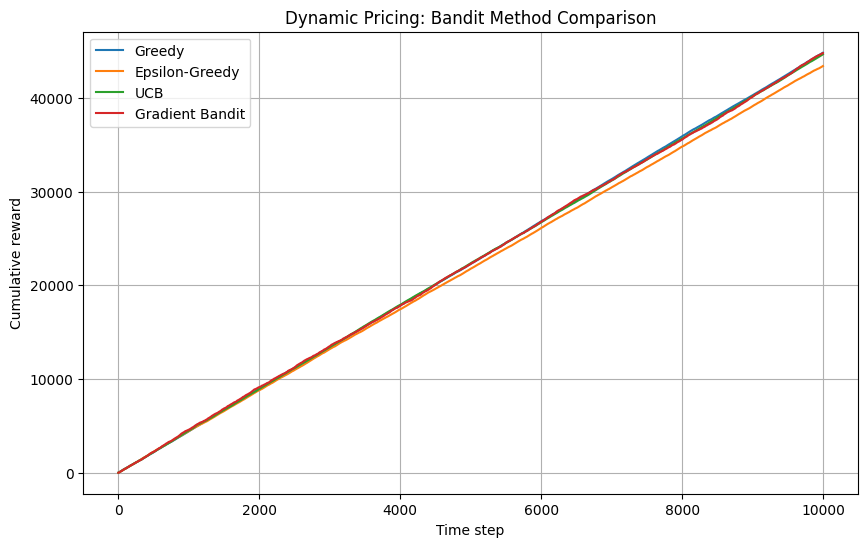

In [28]:
plt.figure(figsize=(10, 6))

for name, result in results.items():
  plt.plot(result["cumulative_rewards"], label=name)

plt.xlabel("Time step")
plt.ylabel("Cumulative reward")
plt.title("Dynamic Pricing: Bandit Method Comparison")
plt.legend()
plt.grid(True)
plt.show()

**Pembahasan:**

Agent Greeedy dan UCB adalah agent yang terkuat disusul dengan Gradient Bandit dan terkahir Epsilon-Greedy. Dengan environment yang status, Greedy kebetulan menemukan arm terbaik di fase awal dan reward-nya konsisten tinggi sehingga cimulative reward-nya naik lurus dengan cepat. Di sisi lain, setelah semua arm dicoba dan ketidakpastian mengecil, UCB juga akan mengunci arm terbaik seperti Greedy sehingga mengkeksploitasi arm optimal terus-menerus.

Sedangkan, Gradient Bandit tidak langsung mengejar reward tertinggi, tetapi belajar membentuk preferensi probabilistik dan selalu ada peluang untuk memilih arm sub-optimal sehingga cumulative reawrd-nya tertinggal dari Greedy dan UCB di awal, tetapi secara jangka panjang, dialah yang terbaik.

Terakhir, di environment yang statis, Epsilon-Greedy dapat sengaja memilih arm yang salah setelah tahu arm yang terbaik berdasarkan nilai epsilon sehingga cumulative reward-nya tertinggal dari agent yang lain.

###Realistic Dynamic Pricing Environment

In [25]:
env = RealisticDynamicPricingEnv(prices)
for name, agent in agents.items():
  results[name] = run(env, agent, steps=10000)

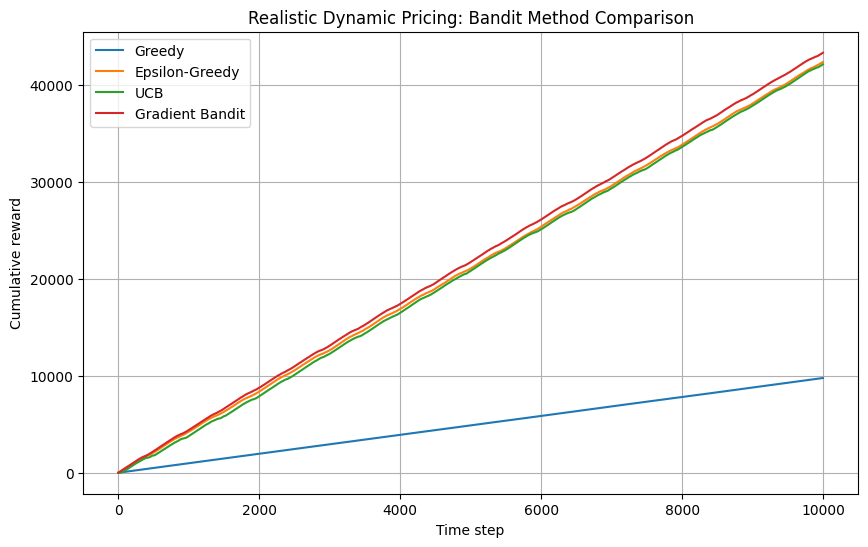

In [26]:
plt.figure(figsize=(10, 6))

for name, result in results.items():
  plt.plot(result["cumulative_rewards"], label=name)

plt.xlabel("Time step")
plt.ylabel("Cumulative reward")
plt.title("Realistic Dynamic Pricing: Bandit Method Comparison")
plt.legend()
plt.grid(True)
plt.show()

**Pembahasan:**

Dengan environment yang non-stationary, Gradient Bandit bisa menyesuaikan distribusi harga dan menggeser probabilitas ke harga yang sedang optimal berdasarkan lingkungan yang berubah.

Di sisi lain, Epsilon-Greedy melakukan eksplorasi konstan sehingga bisa menyesuaikan diri ketika lingkungan berubah, tetapi eksplorasinya dilakukan secara acak sehingga agent tidak belajar sebaik Gradient Bandit.

UCB memiliki asumsi bahwa reward distribution bersifat stasioner sehingga ketika lingkungan berubah, ia lambat beradaptasi karena *overconfident* pada arm yang dulu bagus.

Terakhir, Greedy merupakan agent yang paling lemah karena tidak ada eksplorasi yang dilakukan sehingga salah belajar dan tidak sadar ketika lingkungan sudah berubah.